### Jessica Salguero, UIN: 937005006

# Project Checkpoint 2: Research Question Formation

At this stage, you turn curiosity into clear research questions. Building on what you learned from your dataset and EDA, you’ll define questions that use course methods and stretch a bit further with at least one external data mining method. The goal is to ask questions that are interesting, meaningful, and doable, while also planning how you’ll study them.

## Checkpoint 2: RQ Formation
 
Goal: Define research questions that require both course techniques and externally learned techniques.

Deliverables:
- Written RQ section
- RQ-to-method mapping table (course vs external)
- Method and metric plan
- A fully run Python notebook meeting the requirements specified here. 
- For every algorithmic decision you make, you must document WHY you made that decision. 
- You will be penalized for messiness – make sure your code is professional, well-explained, and well-documented.
- A collaboration declaration for the full notebook is required – this is the same as in the HWs, with one additional item: (1) Collaborators, (2) Web Sources, (3) AI Tools, (4) Citations for any papers that you used.

Rubric: 

[50 pts] Strong/Professional: Correct and complete implementation of the task; Reasonable assumptions, stated or implied, and justified; Thoughtful handling of real-world data issues (missingness, noise, scale, duplicates, edge cases); Clear, concise explanations of what was done and why; Code is clean, readable, and well-structured, uses appropriate pandas, and would plausibly pass a professional code review; Tests meaningfully validate non-trivial behavior (not just "the code runs so it must be right").

[25 pts] Partial/Developing: Core task mostly completed but with gaps, weak assumptions, or minor mistakes; Reasoning is shallow or mostly descriptive; Code works but is messy, repetitive, or fragile; Tests are superficial, incomplete, or poorly motivated.

[0 pts] Minimal/Incorrect: Task is largely incorrect, missing, or misunderstands the goal; Little to no reasoning or justification; Code does not run or ignores constraints; No meaningful tests.

---
## A) Project Scope
#### Brief recap of dataset and EDA findings

- Dataset: Algorithmic Behaviors Across Regions: A Geolocation Audit of YouTube Search for COVID-19 Misinformation between the United States and South Africa
- Course techniques: Supports text mining, graph mining, clustering, and anomaly detection (course)
- External techniques: Supports sequential pattern mining, algorithmic auditing (external)

Additional dataset information:
- Dataset is large-scale, but still able to perform exploratory analysis
- The geographic characteristics of the data can make analysis very interesting, since it has real-world relevancy

Trade-offs:
- Dataset focuses on what people directly search, and limits any information about user engagement or future videos they watch
- Long video titles could make data a bit messier to visualize

EDA Findings: 
- Some videos and channels appear repeatedly across multiple different queries, locations, and audit days.
- The dataset is not extremely sparse, since many videos reappear for the same queries across runs and filters.
- The number of videos collected varies across audit days, which suggests there may be temporal structure in the results.
- The proportion of misinformation-related videos is slightly higher in the U.S. than in South Africa.

---
## B) Research Question Definition

### Propose 3 research questions.
- At least 2 must use course techniques
- At least 1 must require an external technique

#### Research Questions: 
- RQ1: What frequent groups of videos or channels appear together in YouTube search results, and do these patterns differ between countries or search queries? 
- Data Mining Task Type: Frequent itemset mining
- Relevant Algorithm(s): Apriori (course)
- Evaluation Criteria: Support, total & interpretability of itemsets, comparison of patterns across countries and search queries

- RQ2: What association rules exist between search queries, filters, channels, and misinformation-labeled videos?
- Data Mining Task Type: Association rule mining
- Relevant Algorithm(s): Apriori (course), association rules (course)
- Evaluation Criteria: support, confidence, lift, interpretabilihy of rules

- RQ3: Do patterns across audit runs reveal any time-based trends that are missed by unordered itemset methods?
- Data Mining Task Type: Sequential pattern mining
- Relevant Algorithm(s): PrefixSpan (external)
- Evaluation Criteria: pattern length, number of patterns, interpretability of sequences, comparison between unordered and ordered frequent itemsets

### Additionally, perform any additional EDA you need to in order to find some interesting questions you want to explore.

In [21]:
# load in libraries I'll need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# load in multiple result files to create dataset
youtube_search_results_path = "/Users/jsalguero/Downloads/search-results"
list_of_search_result_files = os.listdir(youtube_search_results_path) # 12 zip files

# combine result files into one dataset
search_result_dfs = []
for i in list_of_search_result_files:
    # save information from the file names
    # city-bot_num-top50-search-results
    if i.endswith(".csv"): # don't want to do this for any hidden files in the folder
        split_filename = i.split("-")
        #print(i)
        city = split_filename[0]
        bot_num = split_filename[1]
        # 3 cities from USA, 3 cities from South Africa
        if(city == "houston" or city == "losangeles" or city == "jacksonville"):
            country = "USA"
        else:
            country = "South Africa"

        # add the columns to each dataset
        curr_df = pd.read_csv(youtube_search_results_path + "/" + i)
        curr_df["city"] = city
        curr_df["bot_num"] = bot_num
        curr_df["country"] = country

        # to keep all individual dfs and combine them later, add each df into a list
        search_result_dfs.append(curr_df)

# combine into one dataset
youtube_search_result_df = pd.concat(search_result_dfs, ignore_index=True)
#print(youtube_search_result_df)

/var/folders/04/724khnx95b33tvl0d03w3mgc0017vt/T/ipykernel_10148/1037022345.py:28: DtypeWarning: Columns (0: Channel URL) have mixed types. Specify dtype option on import or set low_memory=False.
  curr_df = pd.read_csv(youtube_search_results_path + "/" + i)


#### 1) Misinformation by Search Query
To get a better understanding of how misinformation may be affected by how users search for information, I analyzed how different search queries affected the rate of misinformation. The figure below illustrates the top 10 search queries with the highest rates of misinformation. Looking at the results, some of the top search queries use terms such as "plandemic" and "man-made virus." These results suggest that the wording of a search query can impact the type of content returned, and certain queries are more likely to be associated with misinformation; this supports using association rule mining for my project, since there may be a relationship between search queries and misinformed videos.

Percent of Videos Leading Towards Misinformation Per Search Query:
Search Query
CCP_virus                0.861057
Biological_Weapon        0.801436
herbs                    0.785221
depopulate_the_world     0.673927
man-made_virus           0.577045
plandemic                0.575141
Kungflu                  0.526544
brainwashing             0.501867
vaccines_depopulation    0.481571
population_control       0.462195
Name: count, dtype: float64


Text(0, 0.5, 'Search Query')

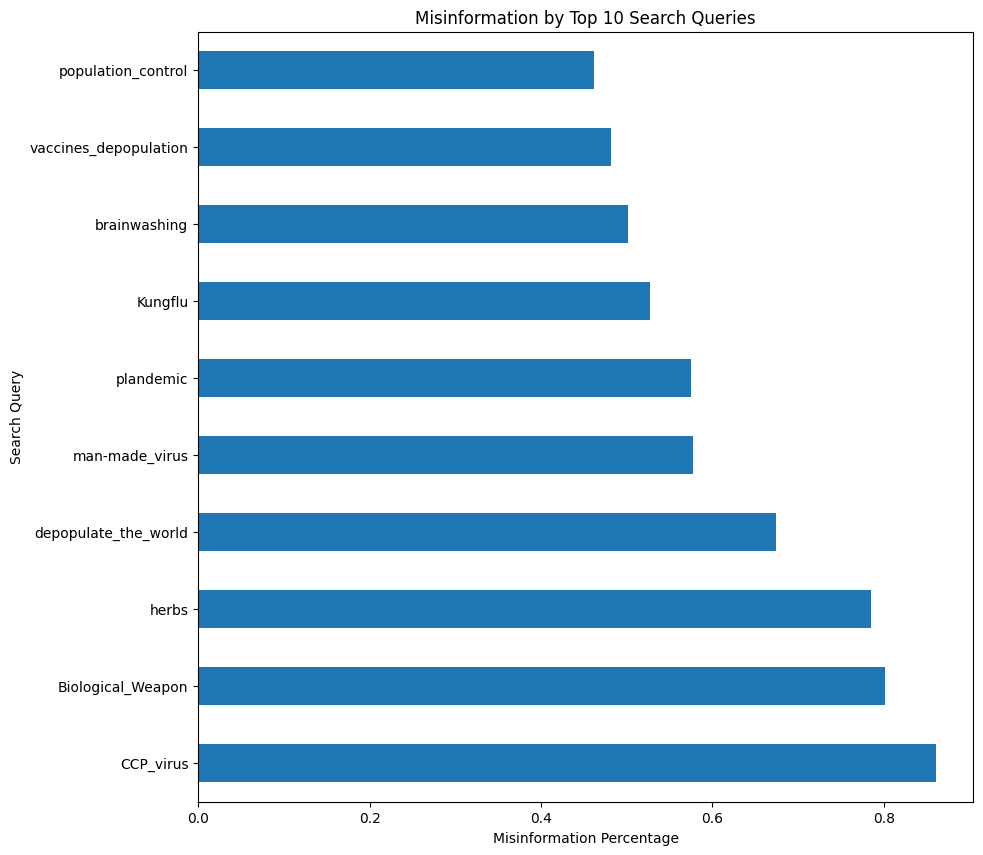

In [22]:
# EDA --> misinformation based on search query
# annotation: 1 = supporting misinformation, 0 = neutral, -1 = opposing misinformation
misinformation = youtube_search_result_df[youtube_search_result_df["annotation"] == 1]

# count by query
misinformation_query_counts = misinformation["Search Query"].value_counts()
video_counts_query = youtube_search_result_df["Search Query"].value_counts()

# final misinformation counts
query_misinformation = (misinformation_query_counts/video_counts_query).fillna(0)
query_misinformation = query_misinformation.sort_values(ascending=False).head(10)
print("Percent of Videos Leading Towards Misinformation Per Search Query:")
print(query_misinformation)

# barchart
plt.figure(figsize=(10,10))
query_misinformation.plot(kind="barh")
plt.title("Misinformation by Top 10 Search Queries")
plt.xlabel("Misinformation Percentage")
plt.ylabel("Search Query")

#### 2) Misinformation by Search Filter
Additionally, to better understand how search settings may also be influencing misinformation, I analyzed how different search filters affect the rate of misinformation. The figure below shows the percentage of videos labeled as supporting misinformation for each search filter. Looking at the results, "Rating" and "Upload Date" filters have higher misinformation rates compared to "View Count" and "Relevance." These results suggest that the way results are sorted can impact the type of content shown, and the "Rating" filter may be more likely to surface misinformation than others. These results support the use of association rule mining in my project, since there may be a relationship between search filters and misinformed videos.

Percent of Videos Leading Towards Misinformation Per Search Filter:
Search Filter Sort-By
Rating         0.424449
Upload Date    0.366393
View Count     0.320389
Relevance      0.154102
Name: count, dtype: float64


Text(0, 0.5, 'Search Filter Sort-By')

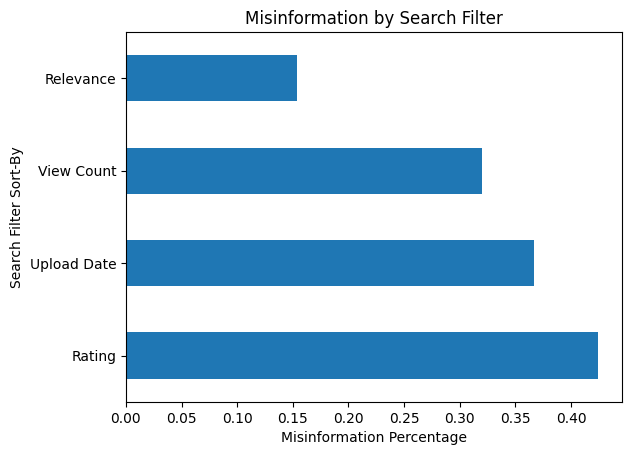

In [23]:
# EDA --> misinformation based on search filter
# annotation: 1 = supporting misinformation, 0 = neutral, -1 = opposing misinformation

# count by filter
misinformation_filter_counts = misinformation["Search Filter Sort-By"].value_counts()
video_counts_filter = youtube_search_result_df["Search Filter Sort-By"].value_counts()

# final misinformation counts
filter_misinformation = (misinformation_filter_counts/video_counts_filter).fillna(0)
filter_misinformation = filter_misinformation.sort_values(ascending=False)
print("Percent of Videos Leading Towards Misinformation Per Search Filter:")
print(filter_misinformation)

# barchart
filter_misinformation.plot(kind="barh")
plt.title("Misinformation by Search Filter")
plt.xlabel("Misinformation Percentage")
plt.ylabel("Search Filter Sort-By")

#### 3) Misinformation by Audit Run 
Lastly, to better understand how misinformation changes over time, I analyzed how the rate of misinformation changes across aduit runs. The figure below shows the percentage of videos labeled as supporting misinformation for each run. Looking at the results, the rate of misinformation remains relatively stable across all audit runs, staying around 0.29 to 0.30 with only small changes. These results support the use of sequential pattern mining in my project, since it allows me to analyze how content varies across audit runs, even when the overall misinformation rate does not change significantly.

Percent of Videos Leading Towards Misinformation Per Audit:
Run #
1     0.296312
2     0.299750
3     0.299647
4     0.299203
5     0.298126
6     0.299965
7     0.303107
8     0.303950
9     0.303208
10    0.301905
Name: count, dtype: float64


(0.0, 1.0)

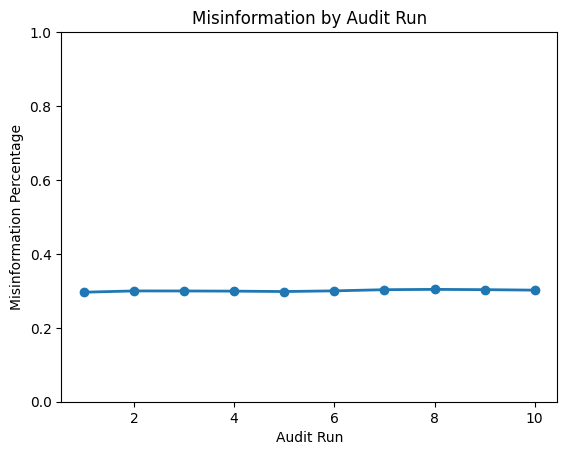

In [24]:
# EDA --> misinformation by audit run
misinformation_by_run = misinformation["Run #"].value_counts()
video_counts_run = youtube_search_result_df["Run #"].value_counts()

# final misinformation counts
run_misinformation = (misinformation_by_run/video_counts_run).fillna(0)
print("Percent of Videos Leading Towards Misinformation Per Audit:")
print(run_misinformation)

# barchart
run_misinformation.plot(marker="o", linewidth=2)
plt.title("Misinformation by Audit Run")
plt.ylabel("Misinformation Percentage")
plt.xlabel("Audit Run")
plt.ylim(0, 1)

---
## C) Motivation and Feasibility

### Motivation
The results from Checkpoint 1 & 2 EDA showed some interesting patterns within the dataset: 
- Rates of misinformation vary based on search query, with certain queries having much higher rates than others.
- "Rating" and "Upload Date" search filters tend to return more misinformation-heavy results compared to "Relevance" and "View Count."
- There are videos and channels that appear repeatedly across the various audit runs.
- The overall rate of misinformation is relatively stable across audit runs

The results from both checkpoints suggest that there is a meaningful structure within this dataset. Misinformation being distributed differently across search queries and filters motivates the use of association rule mining in order to identify significant relationships. Additionally, the stable rates of misinformation across audit runs motivates the use of sequential pattern mining to analyze if patterns change or remain stable over time.

### Non-triviality
The research questions I want to explore are non-trivial, as they do not rely solely on summary-based statistics or basic EDA. I'm planning to use frequent itemset mining to group together videos based on their characteristics, then use association rules to further build on these itemsets and identify clear relationships between these videos and misinformation. Additionally, I want to use sequential pattern mining to see how the order of audit runs may be affecting these relationships over time. 

### Feasibility
The methods I'm planning to use are feasible with this dataset. Similar to checkpoint 1, I am able to group the data into transactions based on search queries and the results, which is essential for frequent itemset mining and association rule mining. Additionally, since the data includes audit runs and the EDA has shown evidence of repeated videos across runs, I should be able to use this dataset to identify meaningful patterns and conduct sequence-based temporal analysis. Overall, the dataset has enough structure and repetition for the methods I'm interested in exploring.

### Risks
There are a few potential risks and challenges working with this dataset. One of the biggest challenges is sparsity, since video titles are typically long and specific. If this issue does arise, I can shift my project to focus on the data at a channel-level rather than focusing on individual videos. 

Additionally, some of the mining techniques can become computationally expensive with a large dataset like this. If this becomes an issue, I can adjust parameters and use subsets of the data to ensure that the results are still manageable and interpretable.

### Additionally perform any additional EDA you need to in order to ensure the method is feasible.

#### Check Sequence Length
To make sure that sequential pattern mining is feasible, I calculated the number of audit runs for each country & search query group. The results show that the average, minimum, and maximum sequence lengths are all 10; this means that every group appears in all audit runs. This is actually ideal for sequential pattern mining, since it allows patterns to be analyzed consistently across all runs without any missing data.

Average Sequence Lengths 10.0
Shortest Sequence Length 10
Longest Sequence Length 10


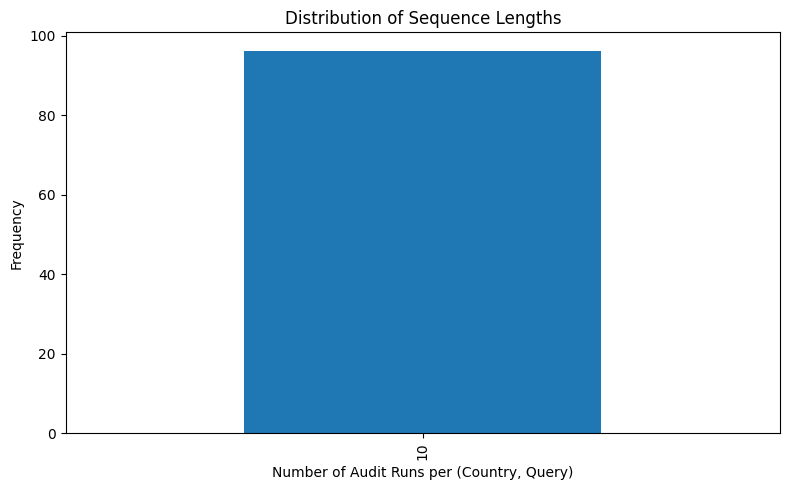

In [25]:
sequence_lengths = youtube_search_result_df.groupby(["country", "Search Query"])["Run #"]
unique_lengths = sequence_lengths.nunique()
avg_lengths = unique_lengths.mean()

print("Average Sequence Lengths", avg_lengths)
print("Shortest Sequence Length", unique_lengths.min())
print("Longest Sequence Length", unique_lengths.max())

plot_counts = unique_lengths.value_counts().sort_index()
plt.figure(figsize=(8, 5))
plot_counts.plot(kind="bar")
plt.title("Distribution of Sequence Lengths")
plt.xlabel("Number of Audit Runs per (Country, Query)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

---
## D) Methodological Planning – Ex:

#### Course algorithms: 
- Apriori for frequent itemset mining and association rule generation
- FP-Growth may be a good alternative to Apriori if the dataset is too computationally intensive

#### External algorithms: 
- PrefixSpan for sequential pattern mining

#### Evaluation:
I want to find patterns that are frequent and useful for understanding how misinformation appears in the dataset.
- Support
- Confidence
- Lift
- Pattern comparison (number of patterns, pattern length, etc.)
- Number of itemsets identified
- Interpretability of rules and sequences

#### Baselines: 
- Frequency of indiviudal videos and channels
- High-support-only mining

### RQ-to-Method Mapping Table

| Research Question | Data Mining Task | Algorithms | Course vs External | Evaluation Criteria |
|------------------|------------------|------------|-------------------|---------------------|
| What frequent groups of videos or channels appear together in YouTube search results, and do these patterns differ between countries or search queries? | Frequent itemset mining | Apriori, FP-Growth | Course | Support, number of itemsets, interpretability, comparison across countries and queries |
| What association rules exist between search queries, filters, channels, and misinformation-labeled videos? | Association rule mining | Apriori + association rule generation | Course | Support, confidence, lift, interpretability |
| Do patterns across audit runs reveal any time-based trends that are missed by unordered itemset methods? | Sequential pattern mining | PrefixSpan | External | Sequential support, pattern length, number of patterns, interpretability |

### Additionally perform any initial method runs (e.g. testing out how packages work, etc.) you need to in order to ensure the methods are feasible.

#### Apriori - Frequent Itemset Mining & Association Rule Mining
To do an initial method test, I kept the same binary transaction format from my homework 2 assignment from this class, adapting it to work with this dataset. Here, each row represents a search query, and each column represents one of the top 20 most frequent channels. A value of 1 means that the channel appeared in the results for that query, while 0 means it did not.

I was able to run the Apriori function and generate initial frequent pairs and association rules. This shows that the dataset can be successfully used for frequent itemset mining and association rule mining.

In [26]:
# Based on HW2: apriori of binary dataframe format
import pandas as pd
# create a binary dataframe using the top 20 most frequent channels
top_20_channels = youtube_search_result_df["Channel Name"].value_counts().head(20).index

youtube_search_result_df_filtered = youtube_search_result_df[youtube_search_result_df["Channel Name"].isin(top_20_channels)][["Search Query", "Channel Name"]].dropna().drop_duplicates()
youtube_search_result_df_filtered["included"] = 1
df_binary = youtube_search_result_df_filtered.pivot(index="Search Query",columns="Channel Name",values="included").fillna(0).astype(int)
df_binary.index.name = "search_query"

# Print or display the dataframe, and answer the following questions about how the data is structured: 
# what are the rows? What are the columns? How do you print which items are part of receipt 1, receipt 2, etc.?
# Each row is one transaction from a search query
# There are multiple columns: 
    # search_query keeps track of the unique identifier for each query, 
    # there are additional columns for each of the top 20 channels. Each keeps track of the inclusion
    # of its corresponding channel within each transaction.
        # 1 = included in transaction, 0 = not included.
print("Binary Dataframe: ", df_binary)

# print items in each search query
for indx in df_binary.index:
    purchased = list(df_binary.columns[df_binary.loc[indx] == 1])
    print("search_query: ", indx, ", items: ", purchased, sep="")


def apriori_binary_format(data: pd.DataFrame, debug: bool, minsup: float, minconf: float):
    if(debug == True):
        print("Separate transactions within the data")

    transactions_dict = {}
    for indx, row in data.iterrows():
        # add each transation to dictionary
        purchased = list(data.columns[row == 1])
        transactions_dict[indx] = purchased

    # the rest of the function remains the same
    # itemset calculations
    # pass 1: Read baskets (transactions) and count in main memory the occurrences of each individual item
    if(debug == True):
        print("Pass 1: Read baskets (transactions) and count in main memory the occurrences of each individual item")
    
    # count the occurrences of each individual item
    item_occurrences = {}
    for item in transactions_dict.values():
        for indiv in item:
            if indiv in item_occurrences:
                item_occurrences[indiv] += 1
            else:
                item_occurrences[indiv] = 1

    if(debug == True):
        print("Determining frequent items. Pass 1 minsup comparison")
    frequent_items = []
    items_pruned = []
    for item in item_occurrences.keys():
        if(item_occurrences[item] >= minsup):
            frequent_items.append(item)
        else: 
            items_pruned.append(item)
    if(debug == True):
        print("Frequent items: ", frequent_items, ", minsup: ", minsup, sep="")
        print("Pruned items: ", items_pruned,  ", minsup: ", minsup, sep="")

    # pass 2: Read baskets again and count in main memory only those pairs where both elements are frequent (from Pass 1)
    if(debug == True):
        print("Pass 2: Read baskets (transactions) again and count in main memory only those pairs where both elements are frequent (from Pass 1)")
    
    # count the occurrences of frequent pairs
    from itertools import combinations
    pair_occurrences = {}
    pair_combinations = list(combinations(frequent_items, 2))
    for item in transactions_dict.values():
        for pair in pair_combinations:
            if((pair[0] in item) and (pair[1] in item)):
                if pair in pair_occurrences:
                    pair_occurrences[pair] += 1
                else:
                    pair_occurrences[pair] = 1

    if(debug == True):
        print("Determining frequent pairs. Pass 2 minsup comparison")
    frequent_pairs = []
    pairs_pruned = []
    for pair in pair_occurrences.keys():
        if(pair_occurrences[pair] >= minsup):
            frequent_pairs.append(pair)
        else:
            pairs_pruned.append(pair)
    if(debug == True):
        print("Frequent pairs: ", frequent_pairs, ", minsup: ", minsup, sep="")
        print("Pruned pairs: ", pairs_pruned,  ", minsup: ", minsup, sep="")

    # outputs the association rules
    if(debug == True):
        print("Generating association rules and checking minconf")

    rules_keep = []
    rules_pruned = []
    for pair in frequent_pairs:
        pair_conf_1 = pair_occurrences[pair] / item_occurrences[pair[0]]
        if pair_conf_1 >= minconf:
            rules_keep.append([pair[0], "->", pair[1], pair_conf_1])
        else:
            rules_pruned.append([pair[0], "->", pair[1], pair_conf_1])
            
        pair_conf_2 = pair_occurrences[pair] / item_occurrences[pair[1]]
        if pair_conf_2 >= minconf:
            rules_keep.append([pair[1], "->", pair[0], pair_conf_2])
        else:
            rules_pruned.append([pair[1], "->", pair[0], pair_conf_2])
    if(debug == True):
        print("Valid Association Rules: ", rules_keep, ", minconf: ", minconf, sep="")
        print("Pruned Association Rules: ", rules_pruned,  ", minconf: ", minconf, sep="")

    return rules_keep

# Function works on project data
assoc_rules_binary = apriori_binary_format(df_binary, debug=False, minsup=2, minconf=0.5)
print("Binary Dataframe - Function results for association rules: ", assoc_rules_binary)

Binary Dataframe:  Channel Name                              60 Minutes Australia  BBC News  \
search_query                                                               
5g_and_covid19_link                                          1         0   
5g_bad_effect                                                1         0   
5g_conspiracy                                                1         0   
Biological_Weapon                                            1         0   
CCP_virus                                                    1         1   
China_virus                                                  1         1   
Covid_19_Spread_And_Precautions                              0         0   
Kungflu                                                      0         0   
MRNA                                                         0         0   
North_Carolina_lab_in_US                                     0         0   
WHO_coverup                                                  1       

#### PrefixSpan - Sequence Pattern Mining
To test whether sequential pattern mining would work for this dataset, I ran PrefixSpan on a subset of the data. The full dataset is large and produces large sequences, so I only used the top 20 most frequent channels and shortened the sequence lengths. I grouped the data by country and search query, and created sequences based on their audit run order. With PrefixSpan, I was able to generate several frequent patterns and noticed that there are some channels that appear often, including CNN, Channels Television, Global News, and 60 Minutes Australia. This shows that the dataset should be able to be used for sequential pattern mining.

In [27]:
from prefixspan import PrefixSpan

# it's a large dataset, so I only want to look at the top 20 channels for now
top_20_channels = youtube_search_result_df["Channel Name"].value_counts().head(20).index
youtube_search_result_df_filtered_2 = youtube_search_result_df[youtube_search_result_df["Channel Name"].isin(top_20_channels)]

# build sequences
sequence_data = youtube_search_result_df_filtered_2.sort_values("Run #")
sequence_data = sequence_data.groupby(["country", "Search Query"])["Channel Name"].apply(list)
sequences = sequence_data.tolist()
sequences = [list(dict.fromkeys(seq[:50])) for seq in sequences]

# run PrefixSpan
ps = PrefixSpan(sequences[:20])
patterns = ps.frequent(2)

print("Sequence:")
print(sequences[0])
print("Example patterns:")
print(patterns[:20])

Sequence:
['Channels Television', 'CNN', 'Dr. John Campbell', 'Global News', '60 Minutes Australia', 'WION', 'Sky News Australia']
Example patterns:
[(6, ['Channels Television']), (3, ['Channels Television', 'Global News']), (2, ['Channels Television', 'Global News', '60 Minutes Australia']), (3, ['Channels Television', '60 Minutes Australia']), (2, ['Channels Television', 'Sky News']), (11, ['CNN']), (4, ['CNN', 'Dr. John Campbell']), (2, ['CNN', 'Dr. John Campbell', 'Global News']), (2, ['CNN', 'Dr. John Campbell', '60 Minutes Australia']), (4, ['CNN', 'Global News']), (2, ['CNN', 'Global News', '60 Minutes Australia']), (4, ['CNN', '60 Minutes Australia']), (2, ['CNN', '60 Minutes Australia', 'India Today']), (4, ['CNN', 'WION']), (2, ['CNN', 'WION', '60 Minutes Australia']), (2, ['CNN', 'Sky News Australia']), (3, ['CNN', 'India Today']), (3, ['CNN', 'BBC News']), (2, ['CNN', 'BBC News', 'Global News']), (4, ['CNN', 'CGTN'])]


## Citations

1) Collaborators:

2) Web Sources:
- data: https://github.com/social-comp/YouTubeAuditGeolocation-data
- https://www.geeksforgeeks.org/python/python-list-files-in-a-directory/
- https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html
- https://mode.com/python-tutorial/counting-and-plotting-in-python
- https://www.geeksforgeeks.org/nlp/co-occurence-matrix-in-nlp/
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html
- https://www.geeksforgeeks.org/pandas/python-pandas-dataframe-groupby/
- https://stackoverflow.com/questions/48655801/tables-in-markdown-in-jupyter
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.nunique.html
- https://www.geeksforgeeks.org/data-analysis/what-is-support-and-confidence-in-data-mining/
- https://www.geeksforgeeks.org/machine-learning/implementing-apriori-algorithm-in-python/
- https://pypi.org/project/prefixspan/
- https://github.com/chuanconggao/PrefixSpan-py
- https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.fpm.PrefixSpan.html
  
3) AI Tools:
- When running the additional EDAs, I used ChatGPT for recommendations on the best ways to visualize the results. This helped me decide when it was best to use bar graphs, line graphs, etc.
- I was having a bit of trouble getting PrefixSpin to work, so I fed my code to ChatGPT and implemented some of the recommended solutions to fix the code.
  
4) Citations for any papers that you used:
- Jung, Hayoung & Juneja, Prerna & Mitra, Tanushree. (2024). Algorithmic Behaviors Across Regions: A Geolocation Audit of YouTube Search for COVID-19 Misinformation Between the United States and South Africa. 10.48550/arXiv.2409.10168. 